# PARTICIPANTES: - Mauricio Bertuci Saletti - RM571229
# - Lucas Caram Bueno - RM570158
# - Rhuan Pacheco Carreri - RM570129
# - Leonardo Fortini Marcelo - RM572566
# - Nicolas Andrade Rodrigues - 572782

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)

SEED = 42
os.makedirs("figuras", exist_ok=True)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25})

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## Análise — Tarefa 1

### Exploração dos dados

Verificação do formato, tipos, valores ausentes, duplicatas, distribuição das classes e comportamento das três entradas.

In [ ]:
df_aneel = pd.read_csv("aneel_classificacao_orange.csv")
print("Linhas e colunas:", df_aneel.shape)
df_aneel.info()
print("\nValores ausentes por coluna:")
print(df_aneel.isna().sum())
print("\nLinhas duplicadas (mesma potência, coordenadas e fonte):", df_aneel.duplicated().sum())

Linhas e colunas: (3876, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas (mesma potência, coordenadas e fonte): 28


In [ ]:
ORDEM = ["Solar", "Eólica", "Hidráulica"]
CORES = {"Solar": "#f2a900", "Eólica": "#2a9d8f", "Hidráulica": "#1d4e89"}

contagem = df_aneel["fonte"].value_counts().reindex(ORDEM)
display(pd.DataFrame({"linhas": contagem, "proporção (%)": (contagem / len(df_aneel) * 100).round(1)}))
resumo = df_aneel.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].agg(["min", "median", "mean", "max"])
display(resumo.reindex(ORDEM).round(2).T)

,linhas,proporção (%)
fonte,,
Solar,1200,31.0
Eólica,1200,31.0
Hidráulica,1476,38.1


fonte                   Solar     Eólica   Hidráulica
potencia_kw min          0.26       0.16         0.99
            median       1.00   29600.00      4000.00
            mean     11679.39   30782.77     75809.16
            max     137480.00  105000.00  11233100.00
latitude    min        -29.84     -33.72       -30.79
            median      -2.06      -7.99       -22.03
            mean        -5.14      -9.90       -21.11
            max          3.83       0.00         3.80
longitude   min        -69.94     -55.93       -64.65
            median     -52.44     -40.69       -50.42
            mean       -49.19     -39.72       -48.93
            max        -35.24       0.00         0.00

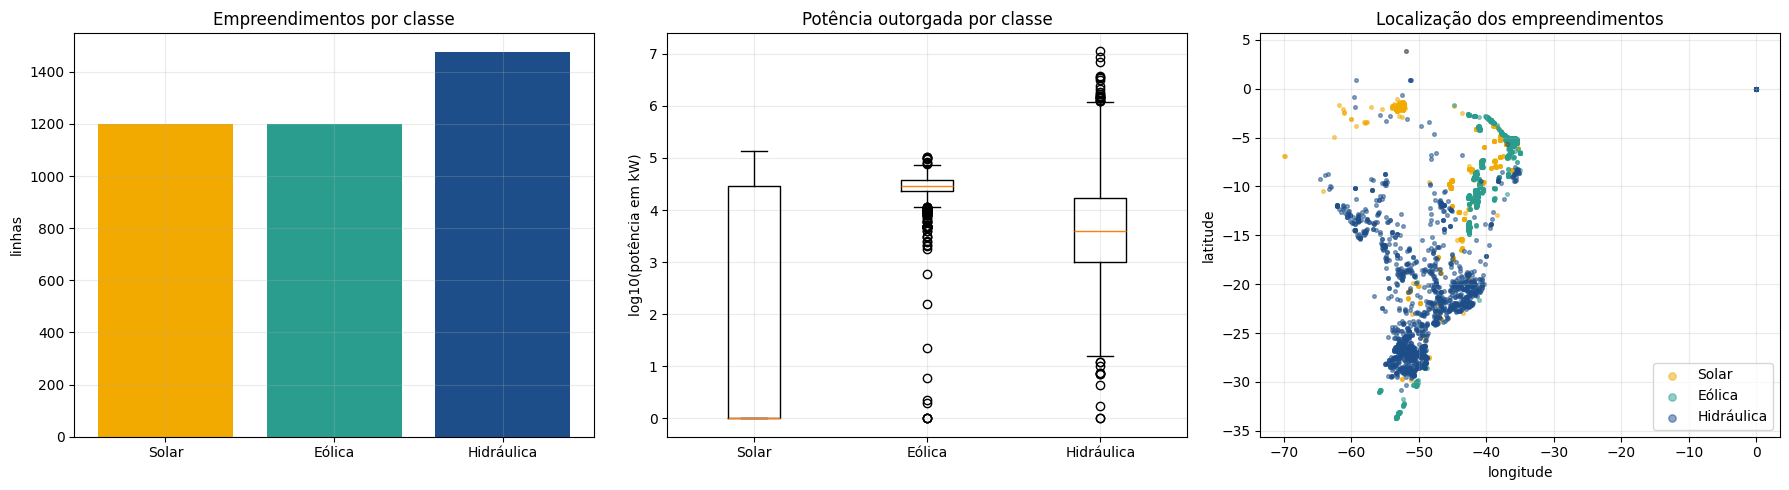

In [ ]:
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

eixos[0].bar(ORDEM, contagem.values, color=[CORES[f] for f in ORDEM])
eixos[0].set_title("Empreendimentos por classe")
eixos[0].set_ylabel("linhas")

dados_box = [np.log10(df_aneel.loc[df_aneel["fonte"] == f, "potencia_kw"].clip(lower=1)) for f in ORDEM]
eixos[1].boxplot(dados_box)
eixos[1].set_xticks([1, 2, 3])
eixos[1].set_xticklabels(ORDEM)
eixos[1].set_title("Potência outorgada por classe")
eixos[1].set_ylabel("log10(potência em kW)")

for f in ORDEM:
    sub = df_aneel[df_aneel["fonte"] == f]
    eixos[2].scatter(sub["longitude"], sub["latitude"], s=7, alpha=0.5, color=CORES[f], label=f)
eixos[2].set_title("Localização dos empreendimentos")
eixos[2].set_xlabel("longitude")
eixos[2].set_ylabel("latitude")
eixos[2].legend(markerscale=2)

plt.tight_layout()
plt.savefig("figuras/aneel_exploracao.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura da exploração.** A potência é muito assimétrica (poucos empreendimentos enormes e muitos pequenos), por isso o boxplot usa escala logarítmica e os modelos sensíveis a escala recebem `log1p(potência)` padronizada. As classes não têm o mesmo tamanho, já que a consulta limita cada sigla a 1.200 registros e a classe Hidráulica reúne três siglas; isso é considerado na escolha das métricas e no uso de `class_weight="balanced"` onde o algoritmo permite. Empreendimentos do mesmo complexo podem compartilhar coordenadas e potência, o que é discutido nas limitações.

### Definição de X e y e divisão treino/teste

`X` contém as três entradas numéricas (`potencia_kw`, `latitude`, `longitude`) e `y` é a coluna `fonte`. A divisão é **estratificada**, 80% treino e 20% teste, com semente fixa. Toda padronização é ajustada apenas no treino, dentro de `Pipeline`.

In [ ]:
X = df_aneel[["potencia_kw", "latitude", "longitude"]]
y = df_aneel["fonte"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
display(pd.DataFrame({"treino": y_treino.value_counts(), "teste": y_teste.value_counts()}).reindex(ORDEM))

,treino,teste
fonte,,
Solar,960,240
Eólica,960,240
Hidráulica,1180,296


### Escolha e Justificativa dos Classificadores
**Regressão Logística:** Modelo linear e robusto, bom como baseline, eficiente e relativamente interpretável, ideal para relações lineares.

**Árvore de Decisão:** Modelo não-linear, fácil de entender e capaz de capturar relações complexas sem escalonamento, mas pode sofrer com overfitting.

**Random Forest:** Algoritmo de ensemble que usa múltiplas árvores de decisão para melhorar a robustez e precisão, reduzindo o overfitting e geralmente oferecendo bom desempenho.

In [ ]:
def preprocessador():
    return ColumnTransformer([
        ("potencia", Pipeline([("log", FunctionTransformer(np.log1p)), ("escala", StandardScaler())]), ["potencia_kw"]),
        ("coordenadas", StandardScaler(), ["latitude", "longitude"]),
    ])

modelos_clf = {
    "Regressão Logística": Pipeline([
        ("prep", preprocessador()),
        ("modelo", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "KNN (k=7)": Pipeline([
        ("prep", preprocessador()),
        ("modelo", KNeighborsClassifier(n_neighbors=7)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
}

linhas = []
previsoes_clf = {}
for nome, modelo in modelos_clf.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)
    previsoes_clf[nome] = pred
    linhas.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(y_teste, pred),
        "Precision (macro)": precision_score(y_teste, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_teste, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_teste, pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_teste, pred, average="weighted", zero_division=0),
    })

res_clf = pd.DataFrame(linhas).set_index("Algoritmo").round(4)
res_clf

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Algoritmo,,,,,
Regressão Logística,0.8196,0.8353,0.8176,0.8156,0.8193
KNN (k=7),0.9652,0.9657,0.9636,0.9644,0.9651
Random Forest,0.9755,0.9768,0.9739,0.9751,0.9755


### Comparação e matrizes de confusão

Precision, Recall e F1 são calculados com **média macro** (média simples entre as três classes, sem ponderar pelo tamanho de cada uma). O F1 *weighted* aparece como referência para mostrar o efeito do desequilíbrio.

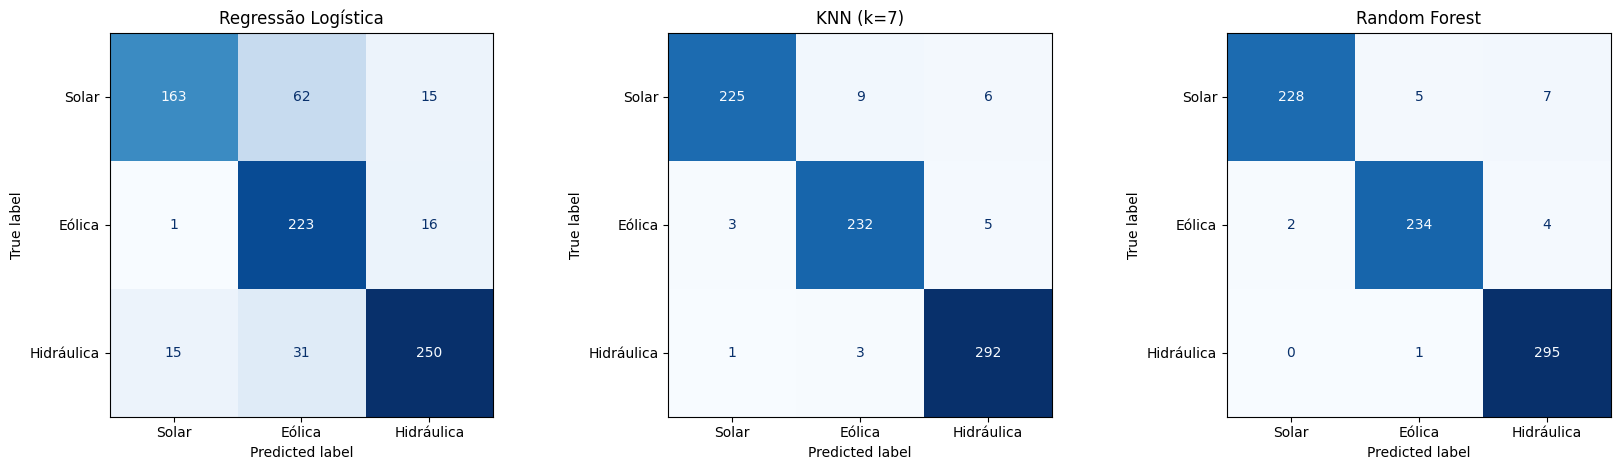

In [ ]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 4.8))
for eixo, (nome, pred) in zip(eixos, previsoes_clf.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_teste, pred, labels=ORDEM, ax=eixo, colorbar=False, cmap="Blues"
    )
    eixo.set_title(nome)
    eixo.grid(False)
plt.tight_layout()
plt.savefig("figuras/aneel_matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
melhor_clf = res_clf["F1 (macro)"].idxmax()
print(f"Relatório por classe — {melhor_clf}")
print(classification_report(y_teste, previsoes_clf[melhor_clf], labels=ORDEM, zero_division=0))

Relatório por classe — Random Forest
              precision    recall  f1-score   support

       Solar       0.99      0.95      0.97       240
      Eólica       0.97      0.97      0.97       240
  Hidráulica       0.96      1.00      0.98       296

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.98       776
weighted avg       0.98      0.98      0.98       776



### Interpretação — classificação

In [ ]:
pred_melhor = previsoes_clf[melhor_clf]
cm = confusion_matrix(y_teste, pred_melhor, labels=ORDEM)
fora = cm.copy()
np.fill_diagonal(fora, 0)
i, j = np.unravel_index(fora.argmax(), fora.shape)
recalls = cm.diagonal() / cm.sum(axis=1)
pior = ORDEM[int(recalls.argmin())]
ranking = " > ".join(f"{n} ({v:.3f})" for n, v in res_clf["F1 (macro)"].sort_values(ascending=False).items())
f1_melhor = res_clf.loc[melhor_clf, "F1 (macro)"]
acc_melhor = res_clf.loc[melhor_clf, "Accuracy"]

texto_clf = f"""**Média das métricas.** Precision, Recall e F1 usam média *macro*; o F1 *weighted* é informado como referência.

**Modelo escolhido.** {melhor_clf}, com o maior F1 macro ({f1_melhor:.3f}) e acurácia de {acc_melhor:.3f}. Ranking por F1 macro: {ranking}.

**Classes mais confundidas.** No melhor modelo, o erro mais frequente é {ORDEM[i]} previsto como {ORDEM[j]}: {fora[i, j]} casos, {fora[i, j] / cm[i].sum():.1%} dos exemplos reais de {ORDEM[i]} no teste. A classe com menor recall é {pior} ({recalls.min():.1%})."""
display(Markdown(texto_clf))

**Média das métricas.** Precision, Recall e F1 usam média *macro*; o F1 *weighted* é informado como referência.

**Modelo escolhido.** Random Forest, com o maior F1 macro (0.975) e acurácia de 0.976. Ranking por F1 macro: Random Forest (0.975) > KNN (k=7) (0.964) > Regressão Logística (0.816).

**Classes mais confundidas.** No melhor modelo, o erro mais frequente é Solar previsto como Hidráulica: 7 casos, 2.9% dos exemplos reais de Solar no teste. A classe com menor recall é Solar (95.0%).

**Limitações de prever a fonte apenas por potência e localização**

- A potência é a capacidade **outorgada** (autorizada), não a energia gerada, e faixas de potência de fontes diferentes se sobrepõem: há usinas solares, eólicas e hidráulicas pequenas e grandes.
- A localização ajuda porque cada fonte tem regiões preferenciais (recurso solar, vento e bacias hidrográficas), mas essas regiões também se sobrepõem. Latitude e longitude não trazem altitude, proximidade de rios, velocidade do vento ou irradiação.
- As coordenadas são aproximadas e o cadastro inclui empreendimentos em fases diferentes. Complexos com várias unidades podem repetir coordenadas e potência, e exemplos parecidos em treino e teste tendem a inflar as métricas.
- A amostra é limitada a 1.200 registros por sigla, então a proporção entre classes não representa a matriz elétrica brasileira, e os resultados valem para este recorte.
- Em uma aplicação real seria preciso incluir variáveis técnicas e ambientais, e o modelo seria uma ferramenta de apoio, não uma substituição do cadastro oficial.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
df_met = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
df_met = df_met.sort_values("data_hora").reset_index(drop=True)
print("Linhas e colunas:", df_met.shape)
print("Período:", df_met["data_hora"].min(), "até", df_met["data_hora"].max())
print("Horas presentes:", sorted(df_met["hora"].unique()))
df_met.info()
print("\nValores ausentes por coluna:")
print(df_met.isna().sum())

Linhas e colunas: (1001, 7)
Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00
Horas presentes: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh

In [ ]:
numericas = df_met.drop(columns="data_hora")
display(numericas.describe().round(2))
display(numericas.corr().round(2))

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,28.89,50.54,55.11,15.47,12.00,472.85
std,3.66,15.91,37.85,4.92,3.16,256.37
min,19.50,21.00,0.00,2.30,7.00,13.00
25%,26.30,38.00,19.00,12.20,9.00,250.00
50%,29.10,49.00,54.00,15.40,12.00,466.00
75%,31.70,61.00,98.00,19.00,15.00,696.00
max,36.10,95.00,100.00,30.10,17.00,1002.00


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
temperatura_c,1.00,-0.93,-0.17,-0.40,0.70,0.64
umidade_pct,-0.93,1.00,0.16,0.22,-0.73,-0.60
nuvens_pct,-0.17,0.16,1.00,0.21,-0.03,-0.18
vento_kmh,-0.40,0.22,0.21,1.00,-0.08,-0.23
hora,0.70,-0.73,-0.03,-0.08,1.00,0.12
radiacao_w_m2,0.64,-0.60,-0.18,-0.23,0.12,1.00


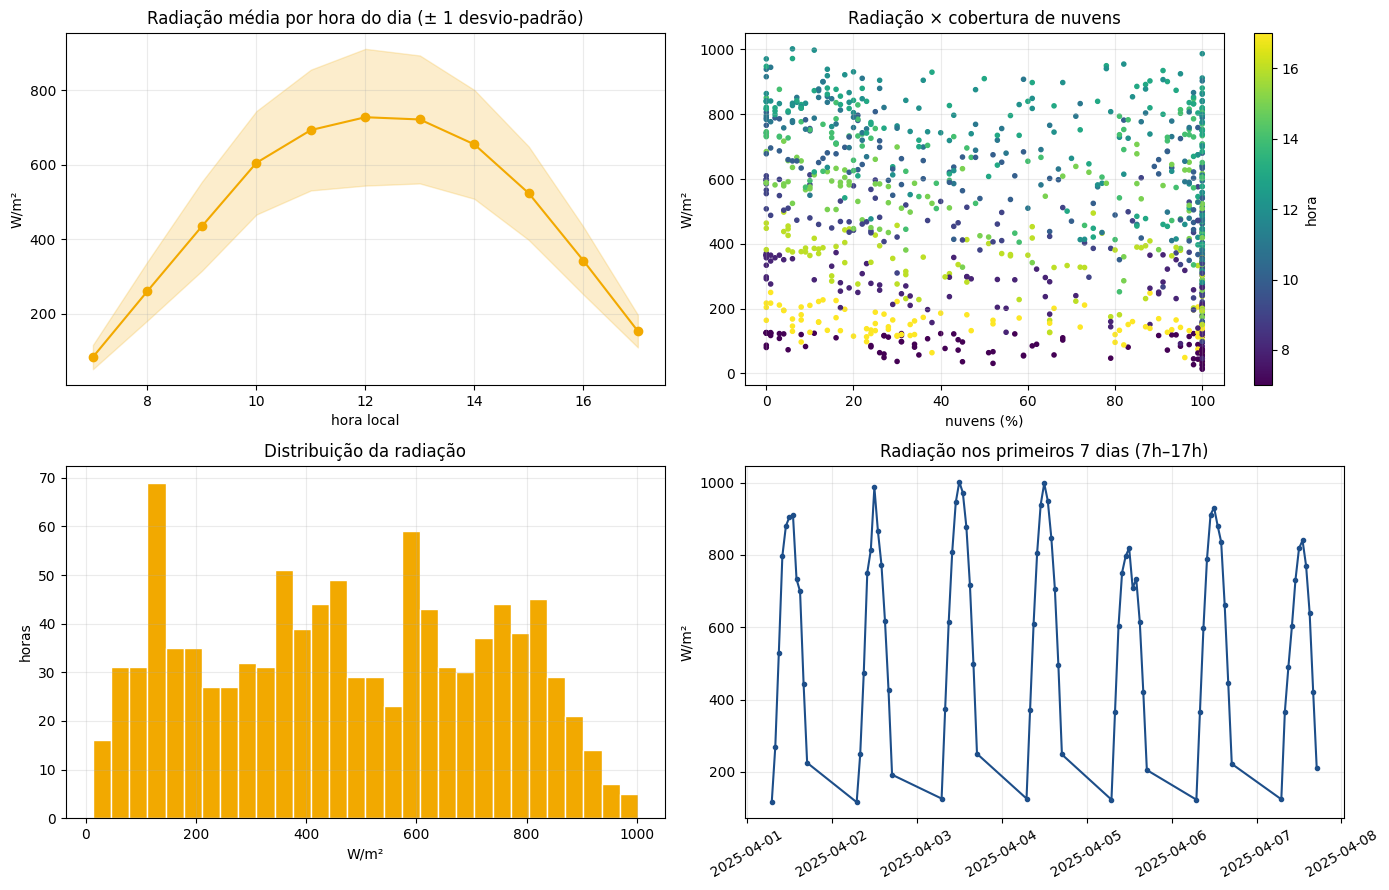

In [ ]:
fig, eixos = plt.subplots(2, 2, figsize=(14, 9))

por_hora = df_met.groupby("hora")["radiacao_w_m2"].agg(["mean", "std"])
eixos[0, 0].plot(por_hora.index, por_hora["mean"], marker="o", color="#f2a900")
eixos[0, 0].fill_between(por_hora.index, por_hora["mean"] - por_hora["std"],
                         por_hora["mean"] + por_hora["std"], alpha=0.2, color="#f2a900")
eixos[0, 0].set_title("Radiação média por hora do dia (± 1 desvio-padrão)")
eixos[0, 0].set_xlabel("hora local")
eixos[0, 0].set_ylabel("W/m²")

pontos = eixos[0, 1].scatter(df_met["nuvens_pct"], df_met["radiacao_w_m2"], c=df_met["hora"], cmap="viridis", s=9)
eixos[0, 1].set_title("Radiação × cobertura de nuvens")
eixos[0, 1].set_xlabel("nuvens (%)")
eixos[0, 1].set_ylabel("W/m²")
fig.colorbar(pontos, ax=eixos[0, 1], label="hora")

eixos[1, 0].hist(df_met["radiacao_w_m2"], bins=30, color="#f2a900", edgecolor="white")
eixos[1, 0].set_title("Distribuição da radiação")
eixos[1, 0].set_xlabel("W/m²")
eixos[1, 0].set_ylabel("horas")

primeiros = df_met.iloc[: 7 * 11]
eixos[1, 1].plot(primeiros["data_hora"], primeiros["radiacao_w_m2"], marker=".", color="#1d4e89")
eixos[1, 1].set_title("Radiação nos primeiros 7 dias (7h–17h)")
eixos[1, 1].set_ylabel("W/m²")
eixos[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("figuras/meteo_exploracao.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura da exploração.** A radiação segue um formato de sino ao longo do dia, com valores baixos no início da manhã e no fim da tarde e máximo perto do meio-dia. Dentro de cada hora, a nebulosidade reduz a radiação, o que aparece como dispersão vertical no gráfico de nuvens colorido por hora. O conjunto não tem valores ausentes depois do tratamento feito na geração do CSV.

### Definição de X e y e divisão temporal

`X` reúne as cinco entradas (`temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`) e `y` é `radiacao_w_m2`. Nenhuma coluna derivada do alvo entra em `X`. Os dados estão ordenados por `data_hora`: as **primeiras 80% das linhas** formam o treino e as **últimas 20%** o teste, sem embaralhar.

In [ ]:
colunas_X = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X = df_met[colunas_X]
y = df_met["radiacao_w_m2"]

corte = int(len(df_met) * 0.8)
X_treino, X_teste = X.iloc[:corte], X.iloc[corte:]
y_treino, y_teste = y.iloc[:corte], y.iloc[corte:]

print("Treino:", len(X_treino), "linhas |", df_met["data_hora"].iloc[0], "->", df_met["data_hora"].iloc[corte - 1])
print("Teste: ", len(X_teste), "linhas |", df_met["data_hora"].iloc[corte], "->", df_met["data_hora"].iloc[-1])

Treino: 800 linhas | 2025-04-01 07:00:00 -> 2025-06-12 14:00:00
Teste:  201 linhas | 2025-06-12 15:00:00 -> 2025-06-30 17:00:00


### Três regressores

| Algoritmo | Por que foi escolhido | Pré-processamento |
|---|---|---|
| Regressão Linear | Referência simples e interpretável; a relação com a hora não é linear, então serve de contraste | padronização |
| Random Forest | Captura relações não lineares e interações entre hora e nebulosidade | nenhum |
| Gradient Boosting | Combina árvores em sequência, corrigindo erros anteriores | nenhum |

Os três usam a mesma divisão temporal.

In [ ]:
modelos_reg = {
    "Regressão Linear": Pipeline([("escala", StandardScaler()), ("modelo", LinearRegression())]),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=SEED
    ),
}

linhas = []
previsoes_reg = {}
for nome, modelo in modelos_reg.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)
    previsoes_reg[nome] = pred
    linhas.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(y_teste, pred),
        "MSE ((W/m²)²)": mean_squared_error(y_teste, pred),
        "R²": r2_score(y_teste, pred),
    })

res_reg = pd.DataFrame(linhas).set_index("Algoritmo").round(4)
res_reg

,MAE (W/m²),MSE ((W/m²)²),R²
Algoritmo,,,
Regressão Linear,145.2049,30034.2011,0.3598
Random Forest,66.3994,7210.0838,0.8463
Gradient Boosting,64.9453,7233.5866,0.8458


### Valores reais × previstos

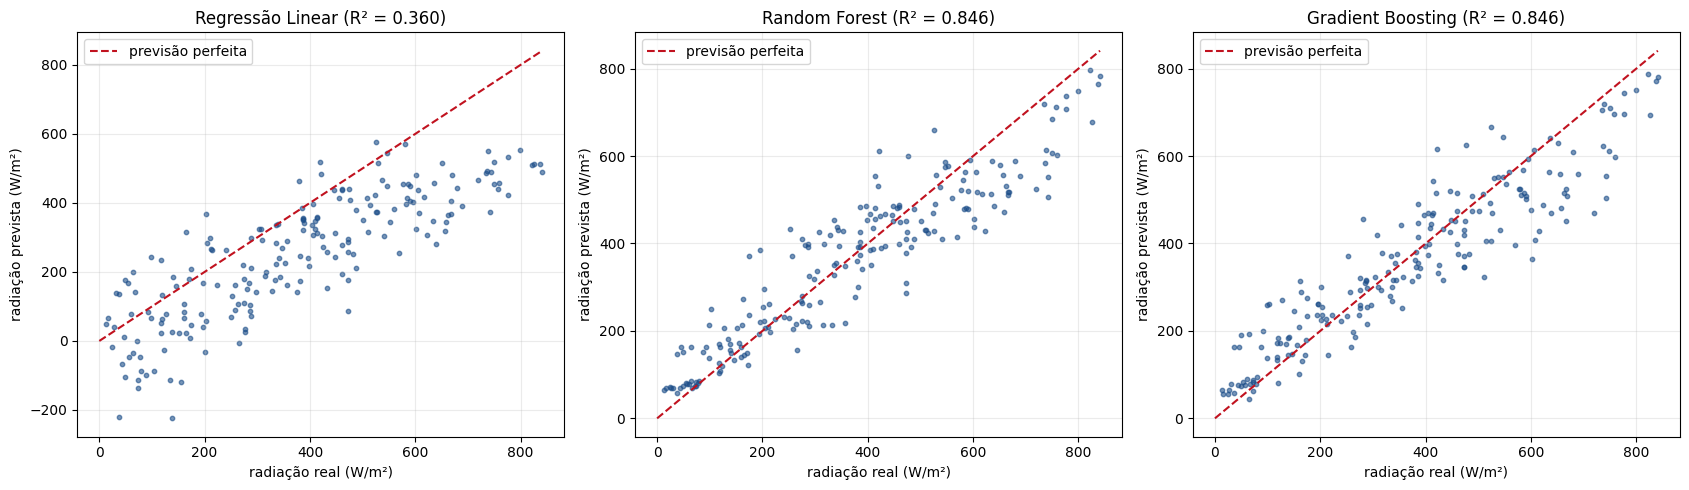

In [ ]:
limite = max(y_teste.max(), max(p.max() for p in previsoes_reg.values()))
fig, eixos = plt.subplots(1, 3, figsize=(17, 5))
for eixo, (nome, pred) in zip(eixos, previsoes_reg.items()):
    eixo.scatter(y_teste, pred, s=10, alpha=0.6, color="#1d4e89")
    eixo.plot([0, limite], [0, limite], color="#c1121f", linestyle="--", label="previsão perfeita")
    eixo.set_title(f"{nome} (R² = {res_reg.loc[nome, 'R²']:.3f})")
    eixo.set_xlabel("radiação real (W/m²)")
    eixo.set_ylabel("radiação prevista (W/m²)")
    eixo.legend()
plt.tight_layout()
plt.savefig("figuras/meteo_real_vs_previsto.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretação — regressão

O gráfico e a tabela abaixo mostram onde o melhor modelo erra mais e quanto cada variável pesa. A importância por permutação mede o aumento do erro no teste quando os valores de uma variável são embaralhados.

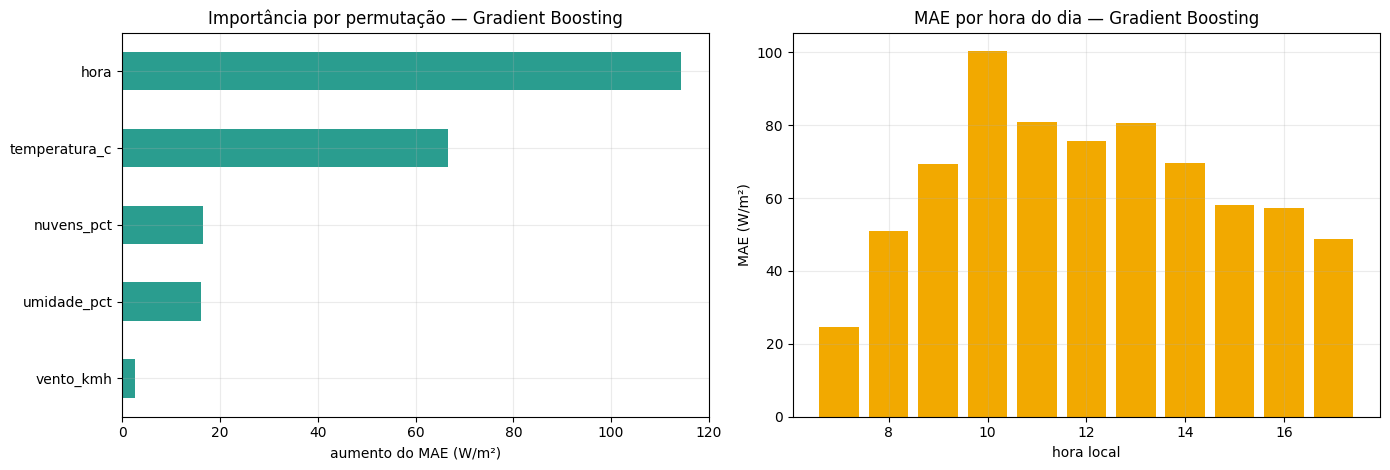

In [ ]:
melhor_reg = res_reg["MAE (W/m²)"].idxmin()
modelo_melhor = modelos_reg[melhor_reg]
pred_melhor = previsoes_reg[melhor_reg]

imp = permutation_importance(modelo_melhor, X_teste, y_teste, n_repeats=20, random_state=SEED,
                             scoring="neg_mean_absolute_error")
importancia = pd.Series(imp.importances_mean, index=colunas_X).sort_values(ascending=False)
mae_por_hora = pd.Series(np.abs(y_teste.values - pred_melhor)).groupby(X_teste["hora"].values).mean()

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8))
importancia.sort_values().plot.barh(ax=eixos[0], color="#2a9d8f")
eixos[0].set_title(f"Importância por permutação — {melhor_reg}")
eixos[0].set_xlabel("aumento do MAE (W/m²)")
eixos[1].bar(mae_por_hora.index, mae_por_hora.values, color="#f2a900")
eixos[1].set_title(f"MAE por hora do dia — {melhor_reg}")
eixos[1].set_xlabel("hora local")
eixos[1].set_ylabel("MAE (W/m²)")
plt.tight_layout()
plt.savefig("figuras/meteo_importancia_erro_hora.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
mae_m = res_reg.loc[melhor_reg, "MAE (W/m²)"]
r2_m = res_reg.loc[melhor_reg, "R²"]
media_teste = y_teste.mean()
media_treino = y_treino.mean()
ranking = " > ".join(f"{n} ({v:.1f})" for n, v in res_reg["MAE (W/m²)"].sort_values().items())
pos_hora = list(importancia.index).index("hora") + 1
hora_pior = int(mae_por_hora.idxmax())

texto_reg = f"""**Modelo escolhido.** {melhor_reg}, com o menor MAE no teste ({mae_m:.1f} W/m², cerca de {mae_m / media_teste:.1%} da radiação média do período de teste, {media_teste:.0f} W/m²) e R² de {r2_m:.3f}. Ranking por MAE: {ranking}.

**Papel da hora.** Pela importância por permutação, `hora` ocupa a posição {pos_hora} de 5 variáveis (aumento de {importancia['hora']:.1f} W/m² no MAE quando embaralhada); a variável mais importante é `{importancia.index[0]}`. A hora funciona como proxy da geometria solar: o ângulo do sol define o formato de sino da radiação ao longo do dia, e as demais variáveis modulam esse padrão (principalmente a nebulosidade). O maior erro médio ocorre às {hora_pior}h ({mae_por_hora.max():.1f} W/m²).

**Cuidado com a divisão temporal.** A radiação média no treino foi {media_treino:.0f} W/m² e no teste {media_teste:.0f} W/m²; o teste corresponde ao fim do período, então mudanças sazonais entre abril e junho afetam a comparação."""
display(Markdown(texto_reg))

**Modelo escolhido.** Gradient Boosting, com o menor MAE no teste (64.9 W/m², cerca de 17.4% da radiação média do período de teste, 373 W/m²) e R² de 0.846. Ranking por MAE: Gradient Boosting (64.9) > Random Forest (66.4) > Regressão Linear (145.2).

**Papel da hora.** Pela importância por permutação, `hora` ocupa a posição 1 de 5 variáveis (aumento de 114.4 W/m² no MAE quando embaralhada); a variável mais importante é `hora`. A hora funciona como proxy da geometria solar: o ângulo do sol define o formato de sino da radiação ao longo do dia, e as demais variáveis modulam esse padrão (principalmente a nebulosidade). O maior erro médio ocorre às 10h (100.3 W/m²).

**Cuidado com a divisão temporal.** A radiação média no treino foi 498 W/m² e no teste 373 W/m²; o teste corresponde ao fim do período, então mudanças sazonais entre abril e junho afetam a comparação.

**Radiação estimada não é geração de energia elétrica**

- A variável prevista é uma potência por área (W/m²) em um plano horizontal, estimada por modelos e reanálise; não é a leitura de um painel. Energia (kWh) exige integrar no tempo e multiplicar pela área e pela eficiência do sistema.
- A geração real depende do painel (eficiência, área, degradação), da inclinação e orientação em relação ao plano horizontal, da temperatura das células (a eficiência cai com o calor), do inversor, de perdas elétricas, de sujeira e sombreamento e de indisponibilidades da rede.
- Os valores são médias da hora anterior em um único ponto (Petrolina) e um período de três meses; não representam outras localidades nem outras estações do ano.
- Para estimar geração seria preciso transformar a radiação prevista em energia com um modelo do sistema fotovoltaico e validar contra medições reais de produção.

# Comparação final e exportação dos resultados

Tabelas com os seis modelos (três por tarefa) e a mesma configuração de avaliação usada em cada uma. Esta célula grava os resultados em CSV e gera o `README.md` do repositório com os valores desta execução.

In [ ]:
print("Classificação — 80/20 estratificado, semente", SEED, "| médias macro")
display(res_clf)
print("Regressão — 80% iniciais (treino) / 20% finais (teste), ordem temporal preservada")
display(res_reg)
res_clf.to_csv("resultados_classificacao.csv", encoding="utf-8-sig")
res_reg.to_csv("resultados_regressao.csv", encoding="utf-8-sig")

Classificação — 80/20 estratificado, semente 42 | médias macro


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Algoritmo,,,,,
Regressão Logística,0.8196,0.8353,0.8176,0.8156,0.8193
KNN (k=7),0.9652,0.9657,0.9636,0.9644,0.9651
Random Forest,0.9755,0.9768,0.9739,0.9751,0.9755


Regressão — 80% iniciais (treino) / 20% finais (teste), ordem temporal preservada


,MAE (W/m²),MSE ((W/m²)²),R²
Algoritmo,,,
Regressão Linear,145.2049,30034.2011,0.3598
Random Forest,66.3994,7210.0838,0.8463
Gradient Boosting,64.9453,7233.5866,0.8458


In [ ]:
def tabela_md(tabela):
    cab = "| " + " | ".join([tabela.index.name] + list(tabela.columns)) + " |"
    sep = "|" + "---|" * (len(tabela.columns) + 1)
    corpo = ["| " + " | ".join([str(idx)] + [f"{v:.4f}" for v in linha]) + " |"
             for idx, linha in zip(tabela.index, tabela.values)]
    return "\n".join([cab, sep] + corpo)

periodo = f"{df_met['data_hora'].min():%d/%m/%Y} a {df_met['data_hora'].max():%d/%m/%Y}"

readme = f"""# APIs, energias renováveis e aprendizado de máquina

## Objetivo

Consultar duas APIs públicas e resolver duas tarefas independentes, comparando três algoritmos em cada uma:

1. **Classificação:** prever a fonte renovável (Solar, Eólica ou Hidráulica) de empreendimentos de geração da ANEEL a partir de potência outorgada, latitude e longitude.
2. **Regressão:** estimar a radiação solar horária (W/m²) em Petrolina (PE) a partir de temperatura, umidade, nuvens, vento e hora do dia.

## Dados

| Tarefa | Fonte | Detalhes |
|---|---|---|
| Classificação | [SIGA — ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) (API CKAN/DataStore) | Até 1.200 registros por sigla (UFV, EOL, UHE, PCH, CGH); {len(df_aneel)} empreendimentos válidos em `aneel_classificacao_orange.csv`. Consulta feita sem token. |
| Regressão | [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) | Petrolina (PE), latitude -9,39 e longitude -40,50, de {periodo}, fuso America/Recife, horas entre 7h e 17h; {len(df_met)} linhas em `meteo_regressao_orange.csv`. Dados estimados por modelos/reanálise, não medidos em painel fotovoltaico. |

Nenhuma das consultas exige credenciais.

## Como executar

```bash
pip install -r requirements.txt
jupyter notebook avaliacao_apis_energia_ml.ipynb
```

Execute todas as células na ordem (Kernel > Restart & Run All). É necessário acesso à internet para consultar as APIs. Os dois CSVs gerados estão no repositório; ao rodar o notebook eles são regenerados e os números da consulta da ANEEL podem variar levemente se o cadastro for atualizado. Figuras ficam em `figuras/` e os resultados em `resultados_classificacao.csv` e `resultados_regressao.csv`.

## Estrutura

- `avaliacao_apis_energia_ml.ipynb`: consulta às APIs, exploração, modelos, métricas, gráficos e interpretação
- `aneel_classificacao_orange.csv` e `meteo_regressao_orange.csv`: dados gerados pelas APIs
- `resultados_classificacao.csv` e `resultados_regressao.csv`: tabelas comparativas
- `figuras/`: gráficos gerados pelo notebook
- `requirements.txt`: dependências

## Tarefa 1 — Classificação da fonte

**Configuração de avaliação:** divisão 80% treino / 20% teste, estratificada por classe, `random_state={SEED}`. Padronização ajustada somente no treino (Regressão Logística e KNN, com `log1p` na potência). Precision, Recall e F1 com média **macro**; F1 weighted como referência.

Algoritmos: Regressão Logística, KNN (k = 7) e Random Forest.

{tabela_md(res_clf)}

{texto_clf}

## Tarefa 2 — Regressão da radiação solar

**Configuração de avaliação:** primeiras 80% das horas para treino e últimas 20% para teste, com ordem temporal preservada. Entradas: temperatura, umidade, nuvens, vento e hora; `radiacao_w_m2` não entra em X.

Algoritmos: Regressão Linear, Random Forest e Gradient Boosting.

{tabela_md(res_reg)}

{texto_reg}

## Limitações

- **Classificação:** a potência é a capacidade outorgada, não energia gerada; potência e localização não distinguem completamente as fontes, as coordenadas são aproximadas, complexos podem repetir coordenadas e a amostra por sigla é limitada.
- **Regressão:** radiação (W/m²) estimada por modelos não equivale à geração elétrica de um sistema fotovoltaico, que depende de eficiência, área, inclinação, temperatura das células, inversor e perdas. O período cobre apenas três meses e um único local.
"""
with open("README.md", "w", encoding="utf-8") as arquivo:
    arquivo.write(readme)
print("README.md gerado")

README.md gerado
